# CSCE 676 - Data Mining Project
## Checkpoint 2: Research Question Formation

**Student:** Tejas Singhal (UIN: 836000009)  
**Course:** CSCE 676 700 - Week 8

### Collaboration Declaration

1.  **Collaborators:** None (Individual work)
2.  **Web Sources:** [UCI Machine Learning Repository - Online Retail II](https://archive.ics.uci.edu/ml/datasets/Online+Retail+II), [Mlxtend Documentation](http://rasbt.github.io/mlxtend/), [PrefixSpan-py Documentation](https://github.com/chuanconggao/PrefixSpan-py)
3.  **AI Tools:** Claude Code (used for brainstorming research questions, reviewing notebook structure, and debugging environment setup).
4.  **Citations:** Han, J., Pei, J., & Yin, Y. (2000). Mining frequent patterns without candidate generation. *ACM SIGMOD Record*. Pei, J., et al. (2001). PrefixSpan: Mining sequential patterns efficiently by prefix-projected pattern growth. *ICDE*.

### 1. Project Scope Recap

Building on the findings from Checkpoint 1, this project explores the **Online Retail II** dataset, which captures transactional data from a UK-based non-store online retail between 2009 and 2011.

**Key EDA Findings from Checkpoint 1:**
- Significant seasonality was observed, with transaction peaks in November and December, suggesting holiday-driven purchasing behavior.
- Most customer baskets are small (under 20 items), but there is a "long tail" of bulk orders that could skew association rules.
- Approximately 243k rows lacked Customer IDs and were removed to enable accurate per-customer tracking.
- A few items like *WHITE HANGING HEART T-LIGHT HOLDER* dominate transaction counts, while most items appear in fewer than 1% of invoices.

**Core Techniques:**
- **Course Techniques:** Frequent Itemset Mining and Association Rules (using Apriori and FP-Growth algorithms).
- **External Technique:** Sequential Pattern Mining (using the PrefixSpan algorithm) to identify temporal purchase orders across multiple customer visits.

### 2. Research Question Definition

These research questions were developed from specific patterns I noticed in my Checkpoint 1 EDA — particularly the strong seasonality, the extreme long-tail item distribution, and the high proportion of repeat customers.

#### **RQ1: Seasonal Differences in Association Rules (Course Technique)**
- **Question:** Do frequent itemsets and association rules differ meaningfully between the holiday peak season (November–December) and the rest of the year? If the item mix shifts seasonally, do we get qualitatively different product associations?
- **Data Mining Task:** Frequent Itemset Mining + Association Rule Mining
- **Relevant Algorithm(s):** FP-Growth (course). I chose FP-Growth over Apriori because with 4,600+ unique StockCodes, Apriori's candidate generation step would be combinatorially expensive. FP-Growth's compressed tree representation avoids that bottleneck.
- **Evaluation Criteria:** Number of itemsets at matched support thresholds across the two periods, overlap of top-k rules, and whether holiday-specific rules surface (e.g., Christmas items co-purchased with gift wrap).
- **Motivation:** In Checkpoint 1, the monthly transaction trend plot showed clear Nov–Dec peaks. If the underlying purchasing *structure* also changes (not just volume), then a single annual model would blur interesting seasonal relationships.

#### **RQ2: Confidence vs. Lift Under a Long-Tail Distribution (Course Technique)**
- **Question:** Given that most items appear in fewer than 1% of invoices while a few dominate, does ranking association rules by lift surface more actionable cross-sell opportunities than ranking by confidence?
- **Data Mining Task:** Association Rule Mining
- **Relevant Algorithm(s):** FP-Growth / Apriori Association Rules (course)
- **Evaluation Criteria:** Comparing the top-10 rules ranked by confidence vs. lift; checking whether high-confidence rules are "trivially" driven by popular items, while high-lift rules capture rarer but more interesting item pairings.
- **Motivation:** Checkpoint 1 showed that *WHITE HANGING HEART T-LIGHT HOLDER* alone appears in ~13% of invoices. High confidence rules involving this item may just reflect its baseline popularity. Lift normalizes for this, and I want to quantify how much the two metrics diverge on this dataset.

#### **RQ3: Temporal Purchase Progressions via Sequential Mining (External Technique)**
- **Question:** Among repeat customers, do sequential patterns reveal temporal buying progressions (e.g., item A purchased first, then item B in a later visit) that are invisible to standard unordered association rules?
- **Data Mining Task:** Sequential Pattern Mining
- **Relevant Algorithm(s):** PrefixSpan (external). I chose PrefixSpan over alternatives like GSP (which uses expensive candidate generation, similar to Apriori's drawback) and SPADE (which requires a vertical database format transformation). PrefixSpan's prefix-projected database approach is both memory-efficient and has a well-maintained Python library.
- **Evaluation Criteria:** Number of length-2+ sequential patterns at various support thresholds, comparison of sequential patterns vs. top co-occurrence itemsets, and business interpretability (e.g., do customers repeatedly reorder the same items, or do they show progression across product categories?).
- **Motivation:** 72.35% of my customers have multiple visits, with a median of 3 visits per customer. Standard association rules treat all of a customer's items as one unordered bag. Sequential mining can distinguish "bought A, *then later* bought B" from "bought A and B together" — which could reveal cross-sell timing opportunities.

### 3. Additional EDA & Feasibility Check

Before finalizing these research questions, I need to verify that the data actually supports them. I'll run targeted EDA for each RQ's core assumption.

#### **3.1 Data Loading and Cleaning**
I will reuse the cleaning pipeline developed in Checkpoint 1, focusing on removing rows without Customer IDs and filtering out cancellations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
try:
    df_raw_1 = pd.read_excel('../Checkpoint 1/online_retail_II.xlsx', sheet_name='Year 2009-2010')
    df_raw_2 = pd.read_excel('../Checkpoint 1/online_retail_II.xlsx', sheet_name='Year 2010-2011')
    df = pd.concat([df_raw_1, df_raw_2], ignore_index=True)
except FileNotFoundError:
    print("Dataset not found at expected path. Please check location.")

# Cleaning Pipeline (same as Checkpoint 1)
df.dropna(subset=['Customer ID'], inplace=True)
df_clean = df[~(df['Invoice'].astype(str).str.startswith('C') | (df['Quantity'] < 0))].copy()
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

print(f"Cleaned Shape: {df_clean.shape}")
print(f"Unique Customers: {df_clean['Customer ID'].nunique()}")
print(f"Unique StockCodes: {df_clean['StockCode'].nunique()}")
print(f"Unique Invoices: {df_clean['Invoice'].nunique()}")

Cleaned Shape: (805620, 8)
Unique Customers: 5881
Unique StockCodes: 4631
Unique Invoices: 36975


#### **3.2 Data Quality Considerations for Mining**

Before running any algorithms, I want to flag a few data issues that are specifically relevant to itemset and sequential mining (beyond the basic cleaning from Checkpoint 1).

In [2]:
# Check: do StockCodes map consistently to Descriptions?
desc_per_stock = df_clean.groupby('StockCode')['Description'].nunique()
inconsistent = (desc_per_stock > 1).sum()
print(f"StockCodes with inconsistent descriptions: {inconsistent} out of {len(desc_per_stock)}")

# Show a few examples
examples = desc_per_stock[desc_per_stock > 1].head(3)
for sc in examples.index:
    descs = df_clean[df_clean['StockCode'] == sc]['Description'].unique()[:3]
    print(f"  StockCode {sc}: {list(descs)}")

StockCodes with inconsistent descriptions: 624 out of 4631
  StockCode 16011: [' ANIMAL STICKERS', 'ANIMAL STICKERS']


  StockCode 16012: ['FOOD/DRINK SPUNGE STICKERS', 'FOOD/DRINK SPONGE STICKERS']
  StockCode 20615: ['BLUE SPOTTY PASSPORT COVER', 'BLUE POLKADOT PASSPORT COVER']


**Decision:** I will use `StockCode` as the item identifier instead of `Description` for all mining tasks.  
**Why:** 624 out of 4,631 StockCodes map to multiple descriptions (often just typos or trailing spaces, like *"FOOD/DRINK SPUNGE STICKERS"* vs *"FOOD/DRINK SPONGE STICKERS"*). Using StockCode avoids artificially splitting the same product into multiple items, which would deflate support counts and produce spurious rules.

**Note on missing Customer IDs:** The 243k dropped rows (~23% of the original data) likely represent guest or one-time buyers who didn't create accounts. This means my sequential patterns will be biased toward *more engaged* customers who have registered accounts — worth keeping in mind when interpreting results, though it's unavoidable given the data.

#### **3.3 EDA for RQ1: Does the Item Mix Actually Change by Season?**

RQ1 assumes that association rules differ between holiday and non-holiday months. Let me check whether the underlying item distribution shifts enough to expect different rules.

                   n_invoices  n_unique_items  n_rows  avg_basket_size
Non-Holiday             28040            4475  592028             21.1
Holiday (Nov-Dec)        8935            4315  213592             23.9


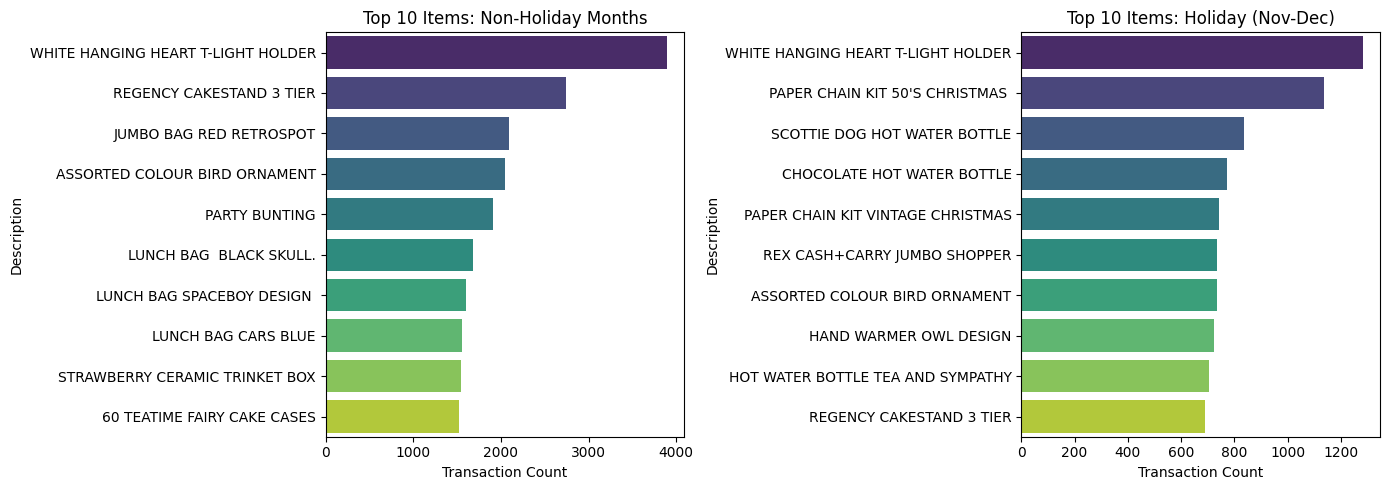

In [3]:
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['IsHoliday'] = df_clean['Month'].isin([11, 12])

# Compare basic stats between periods
season_stats = df_clean.groupby('IsHoliday').agg(
    n_invoices=('Invoice', 'nunique'),
    n_unique_items=('StockCode', 'nunique'),
    n_rows=('Invoice', 'size')
)
season_stats.index = ['Non-Holiday', 'Holiday (Nov-Dec)']

# Average basket size per period
for label, is_hol in [('Non-Holiday', False), ('Holiday (Nov-Dec)', True)]:
    subset = df_clean[df_clean['IsHoliday'] == is_hol]
    avg_basket = subset.groupby('Invoice')['StockCode'].count().mean()
    season_stats.loc[label, 'avg_basket_size'] = round(avg_basket, 1)

print(season_stats)

# Compare top items side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (is_hol, title) in zip(axes, [(False, 'Non-Holiday Months'), (True, 'Holiday (Nov-Dec)')]):
    subset = df_clean[df_clean['IsHoliday'] == is_hol]
    top_items = subset['Description'].value_counts().head(10)
    sns.barplot(x=top_items.values, y=top_items.index, hue=top_items.index,
                palette='viridis', legend=False, ax=ax)
    ax.set_title(f'Top 10 Items: {title}')
    ax.set_xlabel('Transaction Count')
plt.tight_layout()
plt.show()

**Observation:** The holiday period has noticeably different top items — Christmas-specific products like *PAPER CHAIN KIT 50'S CHRISTMAS*, *SCOTTIE DOG HOT WATER BOTTLE*, and *CHOCOLATE HOT WATER BOTTLE* crack the holiday top 10 but don't appear in the non-holiday list at all. Meanwhile, non-holiday bestsellers like *PARTY BUNTING* and *REGENCY CAKESTAND 3 TIER* drop out of the holiday rankings. The average basket size also increases from 21.1 to 23.9 items during the holidays.

**Conclusion for RQ1:** The item mix clearly shifts between seasons — it's not just a volume increase. This justifies running separate association rule analyses for each period to see if the *rules themselves* change qualitatively.

#### **3.4 EDA for RQ2: How Extreme Is the Long-Tail Item Distribution?**

RQ2 depends on the idea that a few items dominate the data while most are rare. If the distribution were more uniform, confidence and lift would agree more often. Let me visualize just how skewed it is.

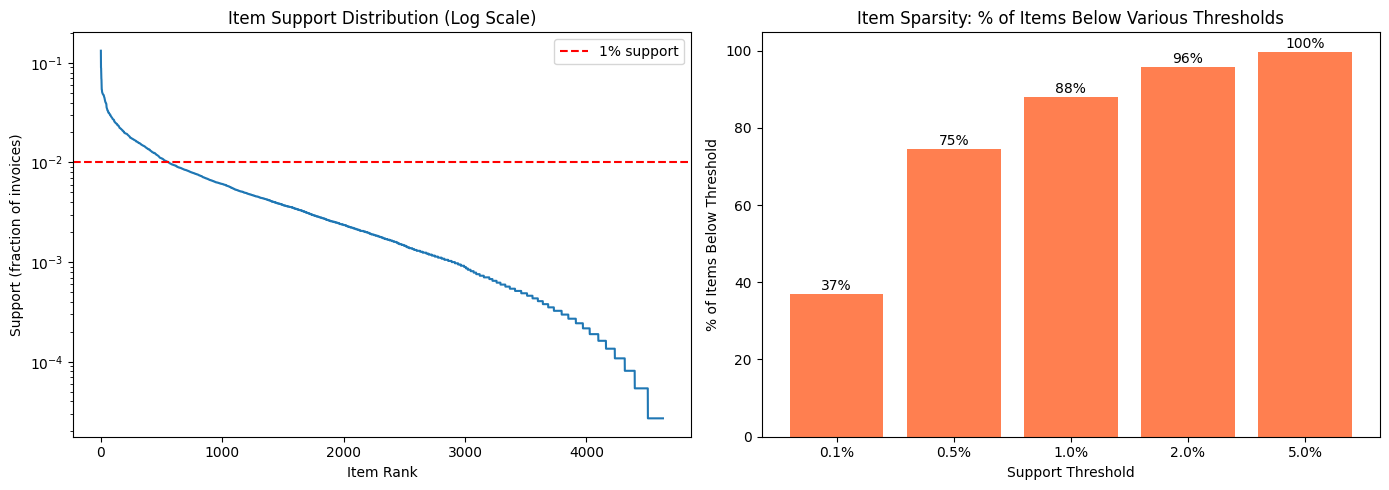

Most frequent item: support = 13.2% (appears in 4895 of 36975 invoices)
Median item support: 0.18%
Items below 1% support: 4072 out of 4631 (87.9%)


In [4]:
n_total_invoices = df_clean['Invoice'].nunique()
item_invoice_freq = df_clean.groupby('StockCode')['Invoice'].nunique().sort_values(ascending=False)
item_support = item_invoice_freq / n_total_invoices

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: log-scale frequency distribution
axes[0].plot(range(len(item_support)), item_support.values)
axes[0].set_yscale('log')
axes[0].set_xlabel('Item Rank')
axes[0].set_ylabel('Support (fraction of invoices)')
axes[0].set_title('Item Support Distribution (Log Scale)')
axes[0].axhline(y=0.01, color='red', linestyle='--', label='1% support')
axes[0].legend()

# Right: percentage of items below various support thresholds
thresholds = [0.001, 0.005, 0.01, 0.02, 0.05]
pcts = [(item_support < t).mean() * 100 for t in thresholds]
axes[1].bar([f'{t*100}%' for t in thresholds], pcts, color='coral')
axes[1].set_xlabel('Support Threshold')
axes[1].set_ylabel('% of Items Below Threshold')
axes[1].set_title('Item Sparsity: % of Items Below Various Thresholds')
for i, v in enumerate(pcts):
    axes[1].text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Most frequent item: support = {item_support.iloc[0]:.1%} (appears in {item_invoice_freq.iloc[0]} of {n_total_invoices} invoices)")
print(f"Median item support: {item_support.median():.2%}")
print(f"Items below 1% support: {(item_support < 0.01).sum()} out of {len(item_support)} ({(item_support < 0.01).mean():.1%})")

**Observation:** The distribution is extremely long-tailed. 87.9% of items appear in fewer than 1% of invoices, while the single most frequent item (*WHITE HANGING HEART T-LIGHT HOLDER*) has 13.2% support. The median item support is just 0.18%.

**Conclusion for RQ2:** This extreme skew means that high-confidence rules will likely be dominated by the handful of very popular items (since confidence = P(B|A), and popular items B have high P(B) regardless of what A is). Lift divides by P(B), which should correct for this and surface genuinely surprising co-occurrences among rarer items. This is worth investigating systematically.

#### **3.5 EDA for RQ3: Repeat Customer Visit Depth**

Sequential mining is only useful if customers have enough visits to form meaningful patterns. I already know 72.35% are repeat purchasers, but I need to check whether they have *enough* visits (ideally at least 3) for non-trivial sequences.

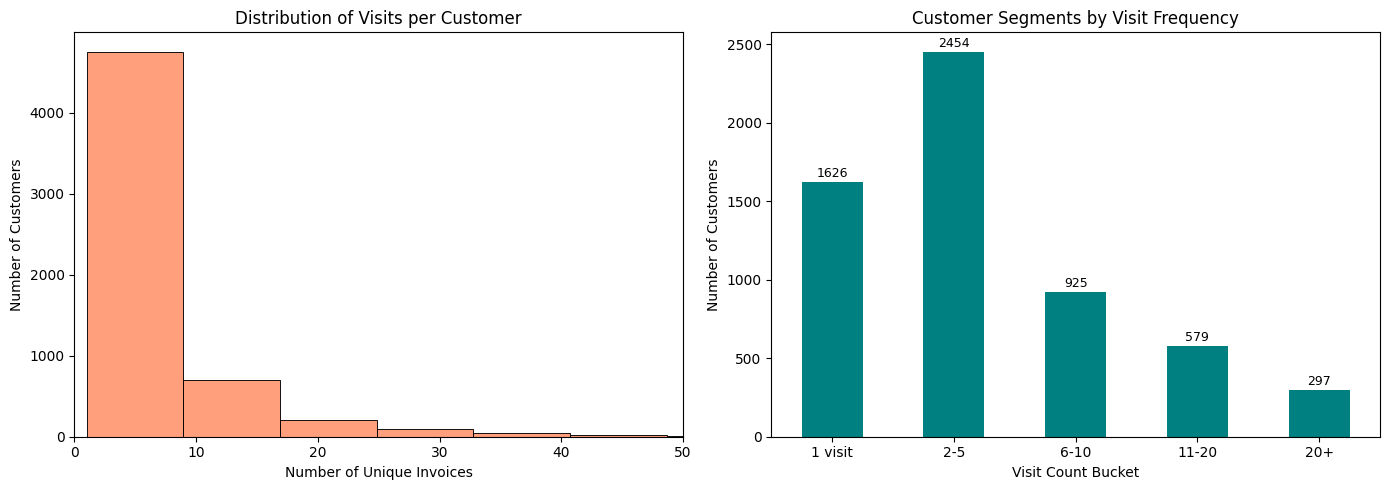

Mean visits per customer: 6.3
Median visits: 3
Customers with >= 3 visits (good for sequences): 3311 (56.3%)


In [5]:
cust_visit_counts = df_clean.groupby('Customer ID')['Invoice'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: distribution of visits per customer
sns.histplot(cust_visit_counts, bins=50, kde=False, color='coral', ax=axes[0])
axes[0].set_title('Distribution of Visits per Customer')
axes[0].set_xlabel('Number of Unique Invoices')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xlim(0, 50)

# Right: breakdown by visit count bucket
buckets = pd.cut(cust_visit_counts, bins=[0, 1, 5, 10, 20, 500],
                 labels=['1 visit', '2-5', '6-10', '11-20', '20+'])
bucket_counts = buckets.value_counts().sort_index()
bucket_counts.plot(kind='bar', color='teal', ax=axes[1])
axes[1].set_title('Customer Segments by Visit Frequency')
axes[1].set_xlabel('Visit Count Bucket')
axes[1].set_ylabel('Number of Customers')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(bucket_counts):
    axes[1].text(i, v + 30, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Mean visits per customer: {cust_visit_counts.mean():.1f}")
print(f"Median visits: {cust_visit_counts.median():.0f}")
print(f"Customers with >= 3 visits (good for sequences): {(cust_visit_counts >= 3).sum()} ({(cust_visit_counts >= 3).mean():.1%})")

**Observation:** 3,311 customers (56.3%) have 3 or more visits, with a mean of 6.3 visits and a median of 3. There are also 297 customers with 20+ visits — these "power users" will produce long, rich sequences. Even the 2-visit customers (the 2–5 bucket has 2,454 customers) can still contribute length-2 patterns.

**Conclusion for RQ3:** The data has more than enough sequential depth for PrefixSpan. I'll focus on customers with at least 3 visits for the main analysis, which still gives me 3,311 customers — a healthy sample.

#### **3.6 Feasibility Summary**

- **Motivation:** Each RQ is directly grounded in a specific EDA finding: seasonality drives RQ1, the long-tail item distribution drives RQ2, and the high repeat-customer rate drives RQ3. Standard course techniques alone would miss the seasonal and temporal dimensions.
- **Non-triviality:** Running a single FP-Growth pass over the full dataset would answer none of these questions. RQ1 requires stratified analysis by time period, RQ2 requires comparing two ranking metrics, and RQ3 requires a fundamentally different algorithm (PrefixSpan).
- **Feasibility:** All three methods are computationally feasible — the dataset fits in memory, libraries are confirmed working, and proof-of-concept runs (below) validate on real data.
- **Risks and Mitigation:**
    - *Parameter sensitivity:* Support thresholds that are too low will cause combinatorial explosion; too high will only find trivial patterns. I'll sweep multiple thresholds (e.g., 0.01, 0.02, 0.05) and report the tradeoff curve.
    - *Dominance of common items:* The long tail means a few items could dominate all rules. For RQ1's seasonal comparison, I may need to filter out the most ubiquitous items to see seasonal differences clearly.
    - *PrefixSpan performance:* With 3,311 eligible customers and average sequence length of ~6 visits, this is manageable. I'll set a minimum support threshold to prune the search space.

### 4. Methodological Planning

#### **4.1 RQ-to-Method Mapping Table**

| Research Question | Data Mining Task | Algorithm | Type | Evaluation Metrics |
| :--- | :--- | :--- | :--- | :--- |
| **RQ1:** Seasonal rule differences | Frequent Itemsets + Association Rules | FP-Growth | Course | Support, rule overlap between seasons, qualitative rule comparison |
| **RQ2:** Confidence vs. Lift under long tail | Association Rule Mining | FP-Growth + Apriori Rules | Course | Confidence, Lift, overlap of top-k rules, presence of high-frequency items in rules |
| **RQ3:** Temporal purchase progressions | Sequential Pattern Mining | PrefixSpan | External | Sequential support, pattern length distribution, comparison with co-occurrence itemsets |

#### **4.2 Method Details**

**Course Algorithms — FP-Growth:**  
I will use `mlxtend.frequent_patterns.fpgrowth` for frequent itemset discovery. I chose FP-Growth over Apriori for this dataset because:
- With 4,631 unique StockCodes, Apriori would generate a massive number of candidates at each level. FP-Growth compresses the transaction database into an FP-tree and mines it directly without candidate generation.
- The dataset's high sparsity (87.9% of items below 1% support) means most branches of the FP-tree will be pruned early, making FP-Growth particularly efficient here.
- I will still use Apriori for RQ2 as a cross-check to confirm the rule sets are consistent between the two algorithms.

**External Algorithm — PrefixSpan:**  
I will use the `prefixspan` Python library for sequential pattern mining. My reasons for choosing PrefixSpan over other sequential mining algorithms:
- **vs. GSP (Generalized Sequential Patterns):** GSP uses candidate generation similar to Apriori, which would be slow with my 4,600+ item vocabulary.
- **vs. SPADE:** SPADE requires converting to a vertical database format (item → list of (sequence_id, event_id) pairs), which adds memory overhead. PrefixSpan's projected-database approach avoids this.
- The `prefixspan` library supports both `topk()` and `frequent()` APIs, making it easy to mine at different support levels.

**Baselines:**  
For RQ3, I will compare the top sequential patterns against the top co-occurrence itemsets from FP-Growth. If sequential mining only recovers the same items that co-occur frequently, it wouldn't add much. If it surfaces *different* items or meaningful temporal orderings, that demonstrates the added value of the external technique.

#### **4.3 Proof of Concept: Running on Real Data**

Instead of just testing on toy data, I'll run both algorithms on a real sample from the dataset to confirm that the full pipeline works — from data transformation through mining through interpretable output.

In [6]:
from mlxtend.frequent_patterns import fpgrowth, association_rules
from prefixspan import PrefixSpan

# === Part 1: FP-Growth on a real data sample ===
print("=== FP-Growth Proof of Concept ===")

# Sample 2000 invoices to keep this quick
np.random.seed(42)
sample_invoices = np.random.choice(df_clean['Invoice'].unique(), size=2000, replace=False)
df_sample = df_clean[df_clean['Invoice'].isin(sample_invoices)]

# Build the basket matrix (invoice x item, boolean)
basket = df_sample.groupby(['Invoice', 'StockCode'])['Quantity'].sum().unstack().fillna(0)
basket = (basket > 0).astype(bool)
print(f"Basket matrix: {basket.shape[0]} invoices x {basket.shape[1]} items")

# Run FP-Growth
freq_items = fpgrowth(basket, min_support=0.02, use_colnames=True)
print(f"Frequent itemsets at min_support=0.02: {len(freq_items)}")

# Show top 5 with human-readable descriptions
print("\nTop 5 frequent itemsets by support:")
for _, row in freq_items.nlargest(5, 'support').iterrows():
    codes = list(row['itemsets'])
    descs = [df_clean[df_clean['StockCode'] == c]['Description'].mode().iloc[0] for c in codes]
    print(f"  Support={row['support']:.3f} | {descs}")

# Generate association rules
rules = association_rules(freq_items, metric='lift', min_threshold=1.0, num_itemsets=len(freq_items))
print(f"\nAssociation rules found: {len(rules)}")
print("\nTop 3 rules by lift:")
for _, r in rules.nlargest(3, 'lift').iterrows():
    ant_desc = [df_clean[df_clean['StockCode'] == c]['Description'].mode().iloc[0] for c in r['antecedents']]
    con_desc = [df_clean[df_clean['StockCode'] == c]['Description'].mode().iloc[0] for c in r['consequents']]
    print(f"  {ant_desc} -> {con_desc}")
    print(f"    confidence={r['confidence']:.2f}, lift={r['lift']:.1f}")

=== FP-Growth Proof of Concept ===


Basket matrix: 2000 invoices x 3618 items
Frequent itemsets at min_support=0.02: 208

Top 5 frequent itemsets by support:
  Support=0.130 | ['WHITE HANGING HEART T-LIGHT HOLDER']


  Support=0.083 | ['REGENCY CAKESTAND 3 TIER']


  Support=0.081 | ['JUMBO BAG RED RETROSPOT']
  Support=0.074 | ['ASSORTED COLOUR BIRD ORNAMENT']


  Support=0.064 | ['LUNCH BAG RED RETROSPOT']

Association rules found: 48

Top 3 rules by lift:
  ['CHARLOTTE BAG PINK POLKADOT'] -> ['RED RETROSPOT CHARLOTTE BAG']
    confidence=0.63, lift=16.9


  ['RED RETROSPOT CHARLOTTE BAG'] -> ['CHARLOTTE BAG PINK POLKADOT']
    confidence=0.53, lift=16.9


  ['STRAWBERRY CERAMIC TRINKET BOX'] -> ['SWEETHEART CERAMIC TRINKET BOX']
    confidence=0.48, lift=15.4


**Interpretation:** FP-Growth successfully produces itemsets and rules from real data. The top rules by lift show genuinely related products — for example, *CHARLOTTE BAG PINK POLKADOT* → *RED RETROSPOT CHARLOTTE BAG* (two color variants of the same bag) has a lift of ~17, meaning customers who buy one are 17x more likely to also buy the other. This is the kind of non-obvious pairing that confidence alone might miss if one of the items were very popular on its own.

In [7]:
# === Part 2: PrefixSpan on real customer sequences ===
print("=== PrefixSpan Proof of Concept ===")

# Build sequences: for each repeat customer, create an ordered list of their
# most-purchased item per visit (a simple representation of each visit's focus)
repeat_custs = cust_visit_counts[cust_visit_counts >= 3].index[:500]

sequences = []
for cust in repeat_custs:
    cust_data = df_clean[df_clean['Customer ID'] == cust].sort_values('InvoiceDate')
    # Represent each visit by its top item (by quantity purchased)
    visit_items = cust_data.groupby('Invoice').apply(
        lambda x: x.nlargest(1, 'Quantity')['Description'].iloc[0]
    ).tolist()
    visit_items = [str(v) for v in visit_items if pd.notna(v)]
    if len(visit_items) >= 2:
        sequences.append(visit_items)

print(f"Customer sequences built: {len(sequences)}")
print(f"Average sequence length: {np.mean([len(s) for s in sequences]):.1f} visits")

# Run PrefixSpan with minimum support of 10 customers
ps = PrefixSpan(sequences)
results = ps.frequent(10)
results.sort(key=lambda x: -x[0])

# Show top single-item patterns
singles = [(c, p) for c, p in results if len(p) == 1][:5]
print(f"\nTop 5 single-item sequential patterns (most commonly top-purchased):")
for count, pattern in singles:
    print(f"  Support={count} customers | {pattern}")

# Show length-2+ patterns — the interesting temporal ones
multi = [(c, p) for c, p in results if len(p) >= 2][:10]
print(f"\nTop 10 length-2+ sequential patterns:")
for count, pattern in multi:
    print(f"  Support={count} customers | {pattern}")

=== PrefixSpan Proof of Concept ===


Customer sequences built: 500
Average sequence length: 11.1 visits

Top 5 single-item sequential patterns (most commonly top-purchased):
  Support=55 customers | ['POSTAGE']
  Support=53 customers | ['MINI PAINT SET VINTAGE ']
  Support=41 customers | ['WORLD WAR 2 GLIDERS ASSTD DESIGNS']
  Support=40 customers | ['RABBIT NIGHT LIGHT']
  Support=31 customers | ['Manual']

Top 10 length-2+ sequential patterns:
  Support=20 customers | ['RABBIT NIGHT LIGHT', 'RABBIT NIGHT LIGHT']
  Support=19 customers | ['MINI PAINT SET VINTAGE ', 'MINI PAINT SET VINTAGE ']
  Support=15 customers | ['MINI PAINT SET VINTAGE ', 'RABBIT NIGHT LIGHT']
  Support=14 customers | ['Manual', 'Manual']
  Support=14 customers | ['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE HANGING HEART T-LIGHT HOLDER']
  Support=13 customers | ['RED TOADSTOOL LED NIGHT LIGHT', 'RABBIT NIGHT LIGHT']
  Support=13 customers | ['STRAWBERRY CERAMIC TRINKET BOX', 'STRAWBERRY CERAMIC TRINKET BOX']
  Support=13 customers | ['WORLD WAR 2 

**Interpretation:** PrefixSpan successfully mines sequential patterns from real customer visit histories. The length-2 patterns are revealing:
- The most common sequence is *RABBIT NIGHT LIGHT → RABBIT NIGHT LIGHT* (support=20), meaning 20 customers bought this item as their top purchase across two separate visits. This indicates a repeat-purchase / restocking behavior pattern.
- More interestingly, *MINI PAINT SET VINTAGE → RABBIT NIGHT LIGHT* (support=15) and *RED TOADSTOOL LED NIGHT LIGHT → RABBIT NIGHT LIGHT* (support=13) show cross-product temporal progressions — customers who buy one children's/novelty product tend to come back later for another. This is a relationship that standard association rules would miss because these items don't necessarily appear in the *same* basket.

This confirms that sequential mining adds value beyond standard itemset analysis and validates RQ3's premise.

### 5. Summary and Next Steps

This checkpoint established three research questions, each grounded in specific EDA findings from this dataset:

1. **RQ1** investigates whether the strong seasonality observed in Checkpoint 1 translates into structurally different association rules for holiday vs. non-holiday periods.
2. **RQ2** leverages the extreme long-tail item distribution to test whether lift is a more discriminating metric than confidence for surfacing actionable cross-sell rules.
3. **RQ3** exploits the 72% repeat-customer rate to ask whether temporal patterns (PrefixSpan) reveal purchase progressions invisible to unordered mining.

All three methods have been validated on real data samples. The next checkpoint will involve full implementation and systematic analysis of each research question.